In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

In [13]:
# QFlow results loading and plotting
def load_qflow_results(env_name, alpha, q_agg, time_embed_dim, actor_loss_type, seeds, 
                       metric_name="episode.return", base_dir="qflow-reproduce", use_time_embed=True):
    """
    Load QFlow evaluation results for given configuration across multiple seeds.
    
    Args:
        env_name: Full environment name (e.g., "antmaze-large-navigate-singletask-task1-v0")
        alpha: Alpha hyperparameter value
        q_agg: Q aggregation method ('mean' or 'min')
        time_embed_dim: Time embedding dimension (or None if not used)
        actor_loss_type: Actor loss type (e.g., 'grad')
        seeds: List of seeds to load (e.g., [10001, 20002, ...])
        metric_name: Metric to extract from eval.csv (default: "episode.return")
        base_dir: Base directory for results (default: "qflow-reproduce")
        use_time_embed: Whether time embedding is used (default: True)
    
    Returns:
        Dictionary with 'data' (list of DataFrames), 'steps' (common step values), and 'values' (metric values per seed)
    """
    results = []
    all_data = []
    
    # Construct env_short name (matching main.py logic)
    env_short = env_name.replace('-singletask-task', '-t').replace('-singletask', '').replace('-v0', '')
    
    # Format alpha string (matching main.py logic)
    alpha_str = str(int(alpha)) if isinstance(alpha, (int, float)) and alpha == int(alpha) else str(alpha)
    
    # Format time_embed string
    if use_time_embed and time_embed_dim is not None:
        time_embed_str = str(time_embed_dim)
    else:
        time_embed_str = 'na'
    
    root_dir = os.path.join(base_dir, "qflow", env_name)
    
    print(f"Loading results from: {root_dir}")
    print(f"Configuration: alpha={alpha}, q_agg={q_agg}, time_embed={time_embed_str}, actor_loss={actor_loss_type}")
    
    for seed in seeds:
        # Construct exp_name (matching main.py logic)
        exp_name = f"qflow-{env_short}-a{alpha_str}-qagg{q_agg}-te{time_embed_str}-al{actor_loss_type}-sd{seed}"
        eval_results_path = os.path.join(root_dir, exp_name, "eval.csv")
        
        if os.path.exists(eval_results_path):
            try:
                df = pd.read_csv(eval_results_path)
                all_data.append(df)
                metric_col = f'evaluation/{metric_name}'
                if metric_col in df.columns:
                    results.append(df[metric_col].values)
                    print(f"  Seed {seed}: Loaded {len(df)} evaluation points")
                else:
                    print(f"  Seed {seed}: Warning - metric '{metric_col}' not found in CSV")
                    print(f"    Available columns: {[c for c in df.columns if 'evaluation' in c]}")
                    results.append(None)
            except Exception as e:
                print(f"  Seed {seed}: Error loading CSV - {e}")
                results.append(None)
        else:
            print(f"  Seed {seed}: No results found at {eval_results_path}")
            results.append(None)
    
    # Get common steps (use steps from first valid result)
    steps = None
    for df in all_data:
        if df is not None and 'step' in df.columns:
            steps = df['step'].values
            break
    
    return {
        'data': all_data,
        'steps': steps,
        'values': results,
        'seeds': seeds
    }


def plot_qflow_results(result_dict, metric_name="episode.return", title=None, figsize=(10, 6), 
                       show_mean=True, show_std=True, alpha=0.3):
    """
    Plot QFlow results across seeds.
    
    Args:
        result_dict: Dictionary returned by load_qflow_results
        metric_name: Metric name for title/label
        title: Plot title (if None, auto-generate)
        figsize: Figure size tuple
        show_mean: Whether to show mean line
        show_std: Whether to show std shading
        alpha: Transparency for individual seed lines
    """
    steps = result_dict['steps']
    values = result_dict['values']
    seeds = result_dict['seeds']
    
    if steps is None:
        print("Error: No valid steps found")
        return
    
    # Filter out None values
    valid_indices = [i for i, v in enumerate(values) if v is not None]
    if len(valid_indices) == 0:
        print("Error: No valid results found")
        return
    
    valid_values = [values[i] for i in valid_indices]
    valid_seeds = [seeds[i] for i in valid_indices]
    
    plt.figure(figsize=figsize)
    
    # Plot individual seeds
    for seed, value_array in zip(valid_seeds, valid_values):
        if len(value_array) == len(steps):
            plt.plot(steps, value_array, alpha=alpha, label=f'Seed {seed}', linewidth=1, marker='o')
    
    # Plot mean and std
    if len(valid_values) > 0:
        # Align all arrays to same length
        min_len = min(len(v) for v in valid_values)
        aligned_steps = steps[:min_len]
        aligned_values = [v[:min_len] for v in valid_values]
        
        mean_values = np.mean(aligned_values, axis=0)
        std_values = np.std(aligned_values, axis=0)
        
        if show_mean:
            plt.plot(aligned_steps, mean_values, 'k-', linewidth=2, label='Mean', zorder=10, marker='o')
        
        if show_std and len(valid_values) > 1:
            plt.fill_between(aligned_steps, 
                           mean_values - std_values, 
                           mean_values + std_values, 
                           alpha=0.2, color='gray', label='±1 Std', zorder=5)
    
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel(f'Evaluation {metric_name}', fontsize=12)
    plt.ylim(0, 1)
    if title is None:
        title = f'QFlow Results: {metric_name}'
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return mean_values, std_values


def print_qflow_summary(result_dict, metric_name="episode.return", final_only=False, last_n_steps=None):
    """
    Print summary statistics for QFlow results.
    
    Args:
        result_dict: Dictionary returned by load_qflow_results
        metric_name: Metric name for display
        final_only: If True, only print final value statistics; if False, print all evaluation points
        last_n_steps: If specified (e.g., 3), average over the last N evaluation steps instead of just the final value.
                      Only applies when final_only=True. If None, uses only the final value.
    """
    steps = result_dict['steps']
    values = result_dict['values']
    seeds = result_dict['seeds']
    
    # Filter out None values
    valid_indices = [i for i, v in enumerate(values) if v is not None]
    if len(valid_indices) == 0:
        print("Error: No valid results found")
        return
    
    valid_values = [values[i] for i in valid_indices]
    valid_seeds = [seeds[i] for i in valid_indices]
    
    print(f"\n{'='*60}")
    print(f"QFlow Results Summary: {metric_name}")
    print(f"{'='*60}")
    
    if final_only:
        # Compute values (either final or average of last N steps)
        if last_n_steps is not None and last_n_steps > 1:
            # Average over last N steps
            min_len = min(len(v) for v in valid_values)
            n_steps_to_use = min(last_n_steps, min_len)
            
            if n_steps_to_use < last_n_steps:
                print(f"\nWarning: Only {min_len} evaluation points available, using last {n_steps_to_use} steps instead of {last_n_steps}")
            
            # For each seed, average over the last N steps
            averaged_values = []
            for v in valid_values:
                last_n = v[-n_steps_to_use:]
                averaged_values.append(np.mean(last_n))
            
            mean_final = np.mean(averaged_values)
            std_final = np.std(averaged_values)
            print(f"\nMean: {mean_final:.4f}")
            print(f"Std:  {std_final:.4f}")
            if len(averaged_values) > 1:
                print(f"Min:  {np.min(averaged_values):.4f}")
                print(f"Max:  {np.max(averaged_values):.4f}")
        else:
            # Only show final values
            final_values = [v[-1] for v in valid_values]
            mean_final = np.mean(final_values)
            std_final = np.std(final_values)
            print(f"\nMean: {mean_final:.4f}")
            print(f"Std:  {std_final:.4f}")
            if len(final_values) > 1:
                print(f"Min:  {np.min(final_values):.4f}")
                print(f"Max:  {np.max(final_values):.4f}")
    else:
        # Show statistics at each evaluation point
        min_len = min(len(v) for v in valid_values)
        aligned_values = [v[:min_len] for v in valid_values]
        aligned_steps = steps[:min_len]
        
        mean_values = np.mean(aligned_values, axis=0)
        std_values = np.std(aligned_values, axis=0)
        
        print(f"\nStatistics across {len(valid_seeds)} seeds at each evaluation point:")
        print(f"{'Step':<12} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
        print("-" * 60)
        for i, step in enumerate(aligned_steps):
            point_values = [v[i] for v in aligned_values]
            print(f"{int(step):<12} {mean_values[i]:<12.4f} {std_values[i]:<12.4f} "
                  f"{np.min(point_values):<12.4f} {np.max(point_values):<12.4f}")
        
        # Final summary
        final_values = [v[-1] for v in valid_values]
        mean_final = np.mean(final_values)
        std_final = np.std(final_values)
        print(f"\nFinal Value Summary:")
        print(f"  Mean: {mean_final:.4f}")
        print(f"  Std:  {std_final:.4f}")
        if len(final_values) > 1:
            print(f"  Min:  {np.min(final_values):.4f}")
            print(f"  Max:  {np.max(final_values):.4f}")
    
    print(f"{'='*60}\n")


def print_task_wise_summary(task_results_dict, metric_name="episode.return", 
                            final_only=True, last_n_steps=None):
    """
    Print task-wise performance summary from already-loaded results.
    
    Args:
        task_results_dict: Dictionary with task indices as keys and result_dicts as values
                          e.g., {1: result_dict_task1, 2: result_dict_task2, ...}
        metric_name: Metric name for display
        final_only: If True, only print final value statistics
        last_n_steps: If specified, average over the last N evaluation steps
    """
    print(f"\n{'='*70}")
    print(f"TASK-WISE PERFORMANCE SUMMARY: {metric_name}")
    print(f"{'='*70}")
    
    task_stats = []
    
    for task_idx in sorted(task_results_dict.keys()):
        result_dict = task_results_dict[task_idx]
        values = result_dict['values']
        seeds = result_dict['seeds']
        
        # Filter out None values
        valid_indices = [i for i, v in enumerate(values) if v is not None]
        if len(valid_indices) == 0:
            print(f"\nTask {task_idx}: No valid results found")
            continue
        
        valid_values = [values[i] for i in valid_indices]
        valid_seeds = [seeds[i] for i in valid_indices]
        
        # Compute final or averaged values
        if final_only:
            if last_n_steps is not None and last_n_steps > 1:
                min_len = min(len(v) for v in valid_values)
                n_steps_to_use = min(last_n_steps, min_len)
                final_values = [np.mean(v[-n_steps_to_use:]) for v in valid_values]
            else:
                final_values = [v[-1] for v in valid_values]
        else:
            final_values = [v[-1] for v in valid_values]
        
        mean_val = np.mean(final_values)
        std_val = np.std(final_values)
        min_val = np.min(final_values) if len(final_values) > 1 else final_values[0]
        max_val = np.max(final_values) if len(final_values) > 1 else final_values[0]
        
        task_stats.append({
            'task': task_idx,
            'mean': mean_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'n_seeds': len(valid_seeds)
        })
    
    # Print summary table
    if task_stats:
        print(f"\n{'Task':<8} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12} {'Seeds':<8}")
        print("-" * 70)
        for stat in task_stats:
            print(f"{stat['task']:<8} {stat['mean']:<12.4f} {stat['std']:<12.4f} "
                  f"{stat['min']:<12.4f} {stat['max']:<12.4f} {stat['n_seeds']:<8}")
        
        # Overall statistics
        all_means = [s['mean'] for s in task_stats]
        overall_mean = np.mean(all_means)
        overall_std = np.std(all_means)
        print("-" * 70)
        print(f"{'Overall':<8} {overall_mean:<12.4f} {overall_std:<12.4f} "
              f"{np.min(all_means):<12.4f} {np.max(all_means):<12.4f} {len(task_stats):<8}")
    
    print(f"{'='*70}\n")




    return task_stats


def load_qflow_results_auto(env_name, seeds, metric_name="episode.return", 
                            base_dir="qflow-reproduce", qflow_config_path=None):
    """
    Convenience function to automatically load QFlow results using config from qflow_config.py.
    
    Args:
        env_name: Full environment name (e.g., "antmaze-large-navigate-singletask-task1-v0")
        seeds: List of seeds to load (e.g., [10001, 20002, ...])
        metric_name: Metric to extract from eval.csv (default: "episode.return")
        base_dir: Base directory for results (default: "qflow-reproduce")
        qflow_config_path: Path to qflow_config.py (if None, tries to import from qflow_config)
    
    Returns:
        Dictionary with 'data' (list of DataFrames), 'steps' (common step values), and 'values' (metric values per seed)
    """
    # Try to import qflow_config
    try:
        if qflow_config_path is None:
            import sys
            # Try to add qflow directory to path (assuming notebook is in qflow/scripts/)
            # This works if running from qflow directory or if qflow is in Python path
            try:
                from qflow_config import get_qflow_params, extract_domain_from_env_name
            except ImportError:
                # Try adding parent directory
                import os
                # Get current working directory and try to find qflow_config
                cwd = os.getcwd()
                if 'qflow' in cwd:
                    qflow_dir = cwd[:cwd.find('qflow') + len('qflow')]
                    if qflow_dir not in sys.path:
                        sys.path.insert(0, qflow_dir)
                from qflow_config import get_qflow_params, extract_domain_from_env_name
        else:
            # Load from specified path
            import importlib.util
            spec = importlib.util.spec_from_file_location("qflow_config", qflow_config_path)
            qflow_config = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(qflow_config)
            get_qflow_params = qflow_config.get_qflow_params
            extract_domain_from_env_name = qflow_config.extract_domain_from_env_name
        
        # Extract domain and get params
        domain = extract_domain_from_env_name(env_name)
        params = get_qflow_params(domain)
        
        if not params:
            print(f"Warning: No config found for domain '{domain}'. Using defaults.")
            params = {
                'alpha': 1.0,
                'q_agg': 'mean',
                'time_embed_dim': 64,
                'actor_loss_type': 'grad',
                'use_time_embed': True
            }
        
        print(f"Auto-detected config for domain '{domain}': {params}")
        
        return load_qflow_results(
            env_name=env_name,
            alpha=params.get('alpha', 1.0),
            q_agg=params.get('q_agg', 'mean'),
            time_embed_dim=params.get('time_embed_dim', 64),
            actor_loss_type=params.get('actor_loss_type', 'grad'),
            seeds=seeds,
            metric_name=metric_name,
            base_dir=base_dir,
            use_time_embed=params.get('use_time_embed', True)
        )
    except ImportError as e:
        print(f"Error: Could not import qflow_config. Please specify parameters manually.")
        print(f"  Error: {e}")
        print(f"  You can use load_qflow_results() with explicit parameters instead.")
        return None
    except Exception as e:
        print(f"Error loading config: {e}")
        return None

env_names = {
    'al': 'antmaze-large-navigate-singletask-task',
    'ag': 'antmaze-giant-navigate-singletask-task',
    'hm': 'humanoidmaze-medium-navigate-singletask-task',
    'hl': 'humanoidmaze-large-navigate-singletask-task',
    'as': 'antsoccer-arena-navigate-singletask-task',
    'c1': 'cube-single-play-singletask-task',
    'c2': 'cube-double-play-singletask-task',
    's': 'scene-play-singletask-task',
    'p3': 'puzzle-3x3-play-singletask-task',
    'p4': 'puzzle-4x4-play-singletask-task',
}


Auto-detected config for domain 'antmaze-large-navigate': {'alpha': 0.2, 'use_time_embed': True, 'time_embed_dim': 64, 'q_agg': 'mean', 'actor_loss_type': 'grad', 'discount': 0.99}
Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task1-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=64, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


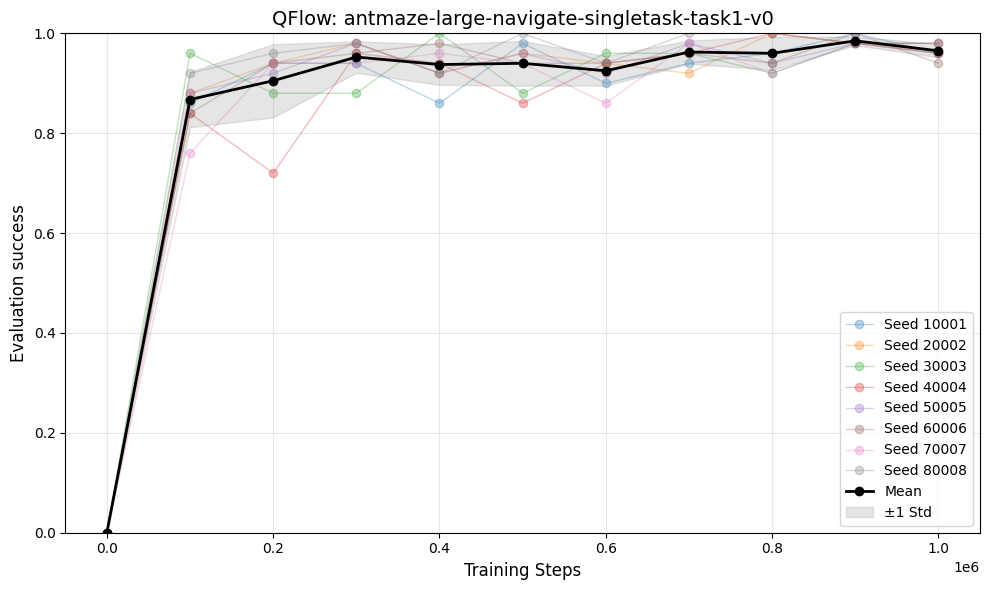

Auto-detected config for domain 'antmaze-large-navigate': {'alpha': 0.2, 'use_time_embed': True, 'time_embed_dim': 64, 'q_agg': 'mean', 'actor_loss_type': 'grad', 'discount': 0.99}
Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task2-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=64, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


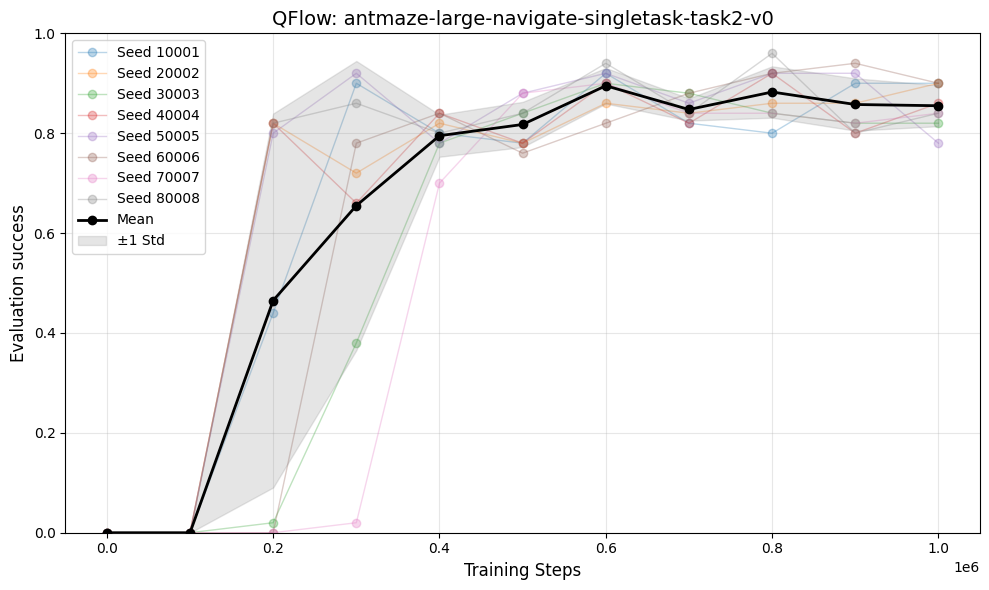

Auto-detected config for domain 'antmaze-large-navigate': {'alpha': 0.2, 'use_time_embed': True, 'time_embed_dim': 64, 'q_agg': 'mean', 'actor_loss_type': 'grad', 'discount': 0.99}
Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task3-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=64, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


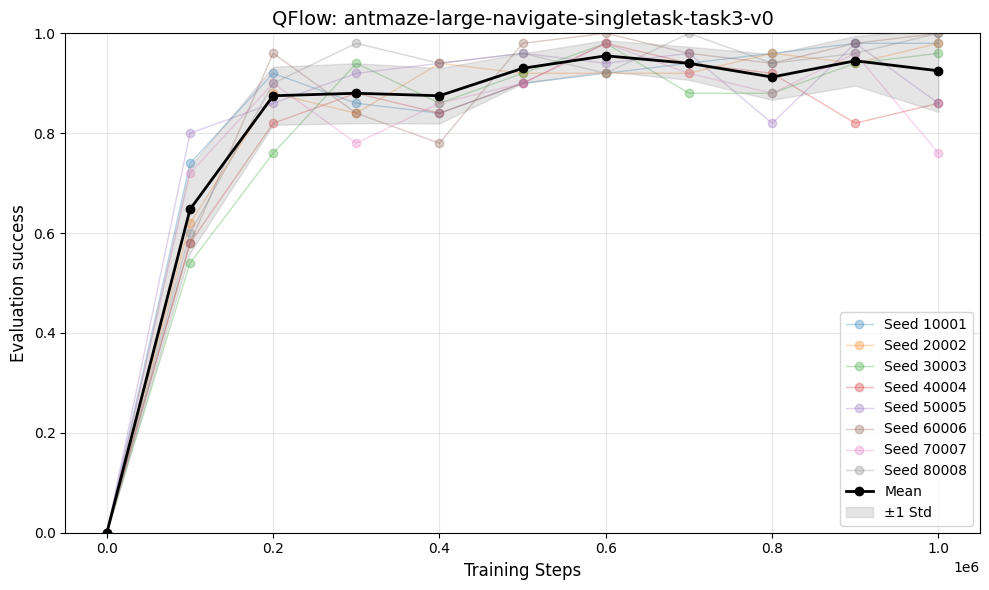

Auto-detected config for domain 'antmaze-large-navigate': {'alpha': 0.2, 'use_time_embed': True, 'time_embed_dim': 64, 'q_agg': 'mean', 'actor_loss_type': 'grad', 'discount': 0.99}
Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task4-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=64, actor_loss=grad
  Seed 10001: Loaded 3 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


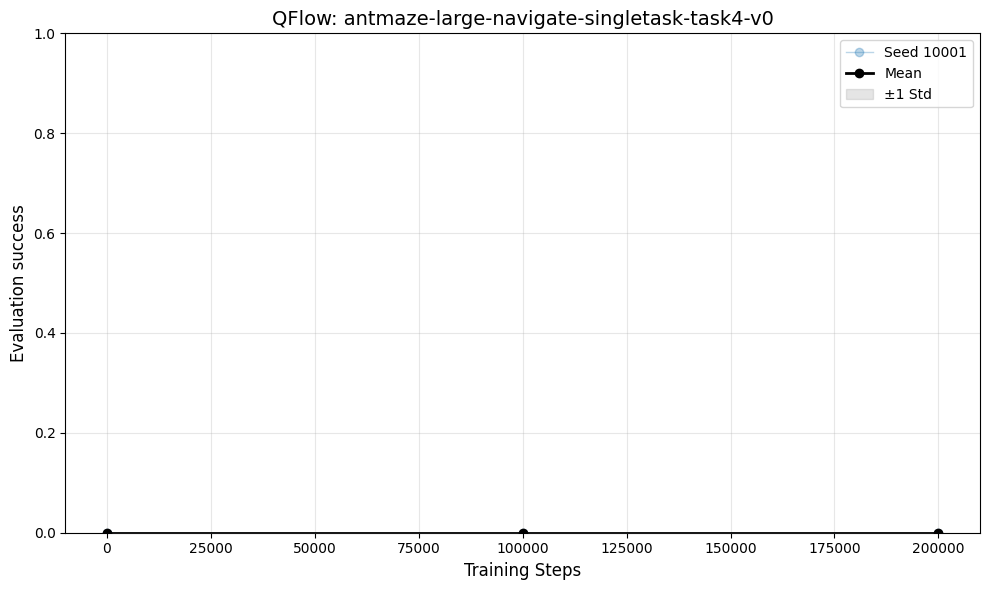

Auto-detected config for domain 'antmaze-large-navigate': {'alpha': 0.2, 'use_time_embed': True, 'time_embed_dim': 64, 'q_agg': 'mean', 'actor_loss_type': 'grad', 'discount': 0.99}
Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task5-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=64, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


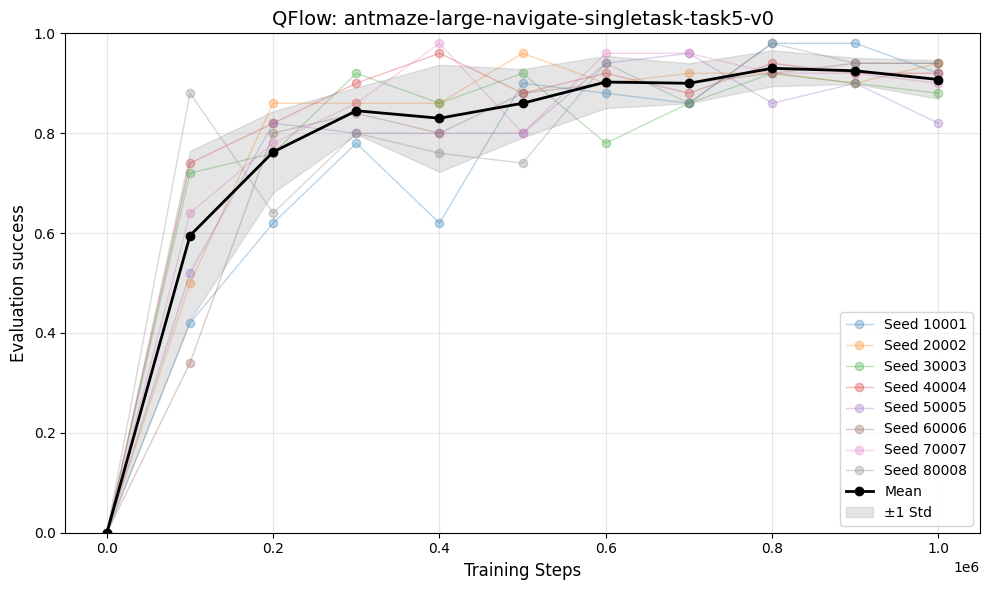


TASK-WISE PERFORMANCE SUMMARY: success

Task     Mean         Std          Min          Max          Seeds   
----------------------------------------------------------------------
1        0.9700       0.0129       0.9533       0.9867       8       
2        0.8650       0.0266       0.8267       0.9200       8       
3        0.9275       0.0445       0.8667       0.9733       8       
4        0.4183       0.4243       0.0000       0.9200       8       
5        0.9208       0.0295       0.8600       0.9600       8       
----------------------------------------------------------------------
Overall  0.8203       0.2038       0.4183       0.9700       5       



In [ ]:
# Example usage: Load multiple tasks and print task-wise summary

target_env = 'al'
task_indices = [1, 2, 3, 4, 5]
seeds = [10001, 20002, 30003, 40004, 50005, 60006, 70007, 80008]
metric_name = "success"

# Load results for each task
task_results = {}
for task_idx in task_indices:
    env_name = f"{env_names[target_env]}{task_idx}-v0"
    results = load_qflow_results_auto(
        env_name=env_name,
        seeds=seeds,
        metric_name=metric_name,
        base_dir="/mnt/nas/jaehyeok/qflow/qflow-reproduce"
    )
    if results is not None:
        task_results[task_idx] = results
        # Print individual task summary
        plot_qflow_results(results, metric_name=metric_name, title=f"QFlow: {env_name}")
        # print_qflow_summary(results, metric_name=metric_name, final_only=True, last_n_steps=3)

# Print task-wise comparison
if task_results:
    print_task_wise_summary(task_results, metric_name=metric_name, final_only=True, last_n_steps=3)

Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task1-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=16, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


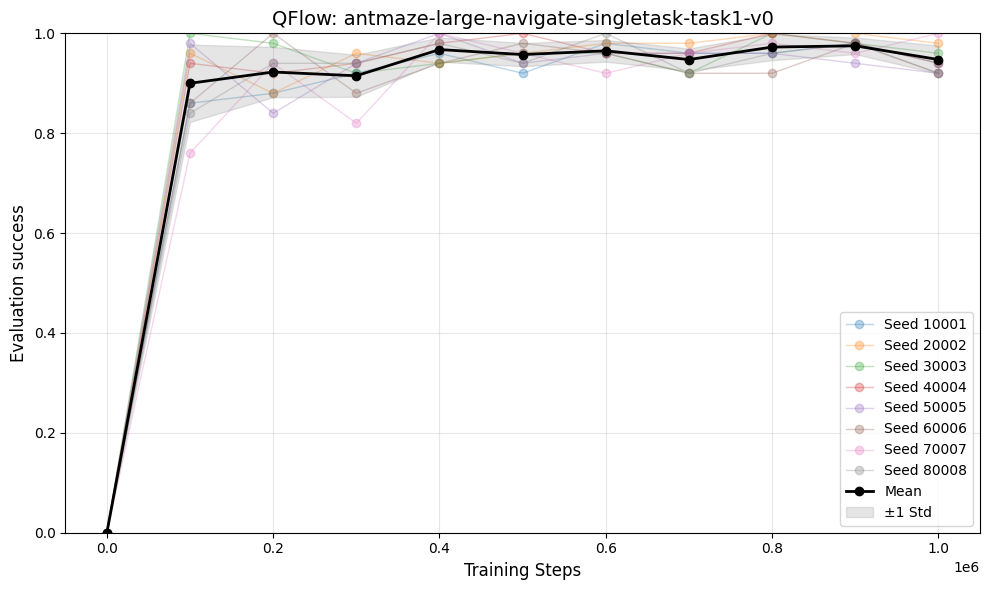

Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task2-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=16, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


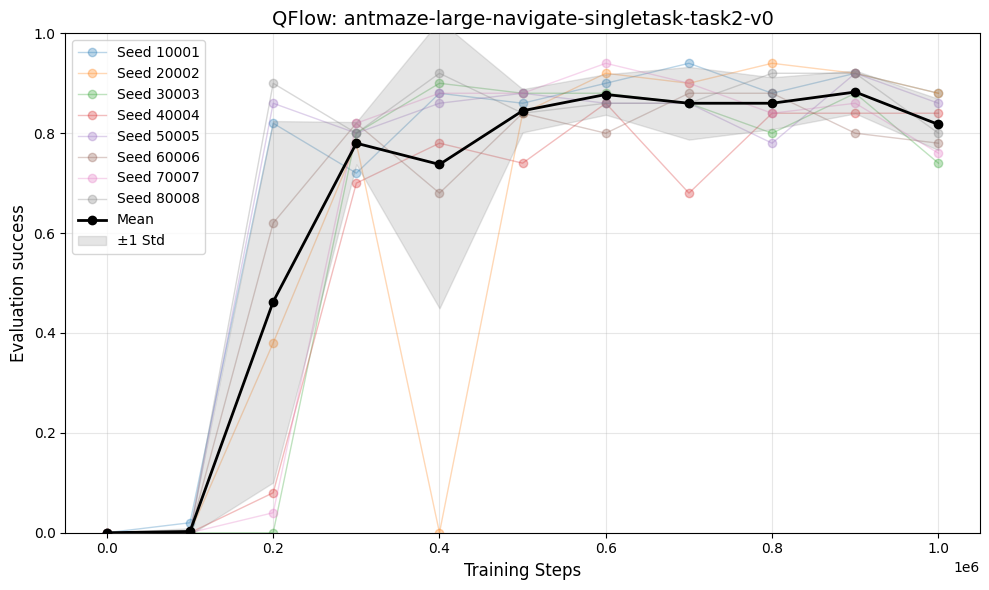

Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task3-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=16, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points


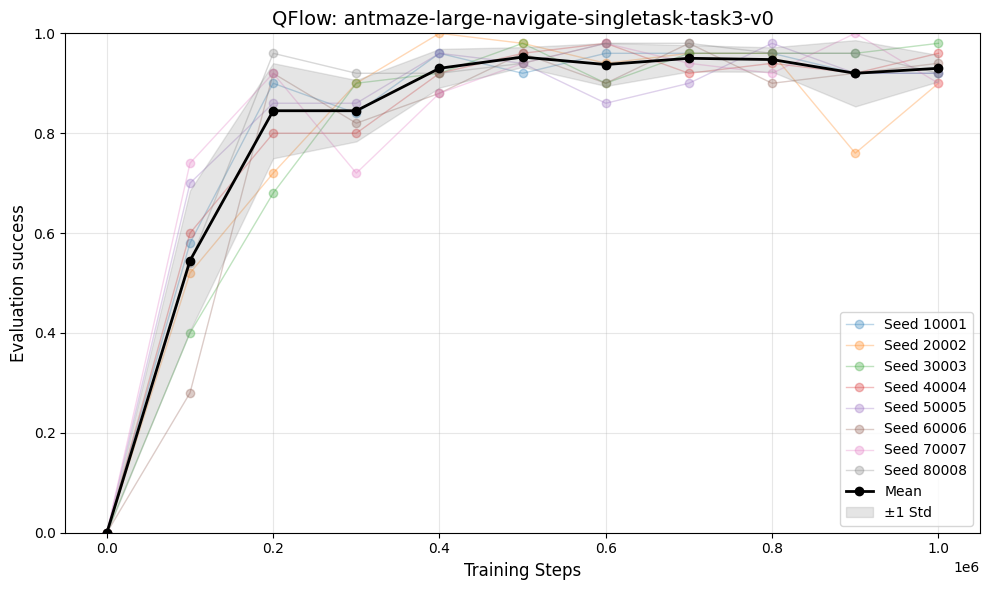


TASK-WISE PERFORMANCE SUMMARY: success

Task     Mean         Std          Min          Max          Seeds   
----------------------------------------------------------------------
1        0.9650       0.0185       0.9400       0.9933       8       
2        0.8533       0.0362       0.8067       0.9133       8       
3        0.9325       0.0255       0.8733       0.9667       8       
----------------------------------------------------------------------
Overall  0.9169       0.0469       0.8533       0.9650       3       



In [11]:
# Example usage: Manual parameter specification for multiple tasks

target_env = 'al'
task_indices = [1, 2, 3]
alpha = 0.2
q_agg = "mean"
time_embed_dim = 16
actor_loss_type = "grad"
seeds = [10001, 20002, 30003, 40004, 50005, 60006, 70007, 80008]
metric_name = "success"

# Load results for each task
task_results = {}
for task_idx in task_indices:
    env_name = f"{env_names[target_env]}{task_idx}-v0"
    results = load_qflow_results(
        env_name=env_name,
        alpha=alpha,
        q_agg=q_agg,
        time_embed_dim=time_embed_dim,
        actor_loss_type=actor_loss_type,
        seeds=seeds,
        metric_name=metric_name,
        base_dir="/mnt/nas/jaehyeok/qflow/qflow-reproduce"
    )
    if results is not None:
        task_results[task_idx] = results
        # Print individual task summary
        plot_qflow_results(results, metric_name=metric_name, title=f"QFlow: {env_name}")
        # print_qflow_summary(results, metric_name=metric_name, final_only=True, last_n_steps=3)

# Print task-wise comparison
if task_results:
    print_task_wise_summary(task_results, metric_name=metric_name, final_only=True, last_n_steps=3)

In [14]:
# Example usage: Load multiple tasks and print task-wise summary

target_env = 'al'
task_indices = [1, 2, 3, 4, 5]
seeds = [10001, 20002, 30003, 40004, 50005, 60006, 70007, 80008]
metric_name = "success"

# Load results for each task
task_results = {}
for target_env, _ in env_names.items():
    for task_idx in task_indices:
        env_name = f"{env_names[target_env]}{task_idx}-v0"
        results = load_qflow_results_auto(
            env_name=env_name,
            seeds=seeds,
            metric_name=metric_name,
            base_dir="/mnt/nas/jaehyeok/qflow/qflow-reproduce"
        )
        if results is not None:
            task_results[task_idx] = results
            # Print individual task summary
            # plot_qflow_results(results, metric_name=metric_name, title=f"QFlow: {env_name}")
            # print_qflow_summary(results, metric_name=metric_name, final_only=True, last_n_steps=3)

    # Print task-wise comparison
    if task_results:
        print_task_wise_summary(task_results, metric_name=metric_name, final_only=True, last_n_steps=3)

Auto-detected config for domain 'antmaze-large-navigate': {'alpha': 0.2, 'use_time_embed': True, 'time_embed_dim': 64, 'q_agg': 'mean', 'actor_loss_type': 'grad', 'discount': 0.99}
Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task1-v0
Configuration: alpha=0.2, q_agg=mean, time_embed=64, actor_loss=grad
  Seed 10001: Loaded 11 evaluation points
  Seed 20002: Loaded 11 evaluation points
  Seed 30003: Loaded 11 evaluation points
  Seed 40004: Loaded 11 evaluation points
  Seed 50005: Loaded 11 evaluation points
  Seed 60006: Loaded 11 evaluation points
  Seed 70007: Loaded 11 evaluation points
  Seed 80008: Loaded 11 evaluation points
Auto-detected config for domain 'antmaze-large-navigate': {'alpha': 0.2, 'use_time_embed': True, 'time_embed_dim': 64, 'q_agg': 'mean', 'actor_loss_type': 'grad', 'discount': 0.99}
Loading results from: /mnt/nas/jaehyeok/qflow/qflow-reproduce/qflow/antmaze-large-navigate-singletask-task2-v0
Configurati